# Demo: Effective Potential with RGE

This notebook demonstrates how to evaluate and visualize the one-loop thermal effective potential $V_{\rm eff}(\phi, T; \mu)$ using `VeffFunc_RGE`.

**Pipeline step:** The effective potential is the second layer — it wraps RGE running and provides the scalar potential to the bounce solvers.

**Module used:** `src/RGE/VeffFunc_RGE.py`

**Structure of $V_{\rm eff}$:**
$$V_{\rm eff}(\phi, T; \mu) = V_{\rm tree}(\phi; \mu) + V_{\rm CW}(\phi; \mu) + V_T(\phi, T) + V_{\rm daisy}(\phi, T)$$
where all couplings are evaluated at scale $\mu$ via the RGE.

**Contents:**
1. Scale variation of the potential at low temperature
2. Thermal corrections: how the potential changes with $T$
3. Saving potential curve data

In [1]:
%load_ext autoreload
%autoreload 2

%run startup.py

startup.py loaded: numpy, scipy, matplotlib, and all project modules are ready.
  Use new_figure() to create pre-formatted plots.


In [2]:
# Instantiate the effective potential with the thermal J_B table
V = veff.VeffRGE(vt_table_path="VT_integralNumeric.dat")

# Model parameters (matching cs.gD0, cs.lambdaS0 defaults)
gD0 = 0.6
ls0 = 0

# Field range for plotting
S = np.linspace(0.0, 5, 10000)

## 1. Scale variation at low temperature

At $T \ll v$, the thermal corrections are negligible and the potential is dominated by the tree + Coleman–Weinberg terms. We use the high-$T$ expanded form `Veff_HighT` here for speed, which coincides with the full potential at low $T$.

The three curves show $\mu = \pi/4,\, \pi,\, 4\pi$ — the spread quantifies the residual renormalization-scale dependence.

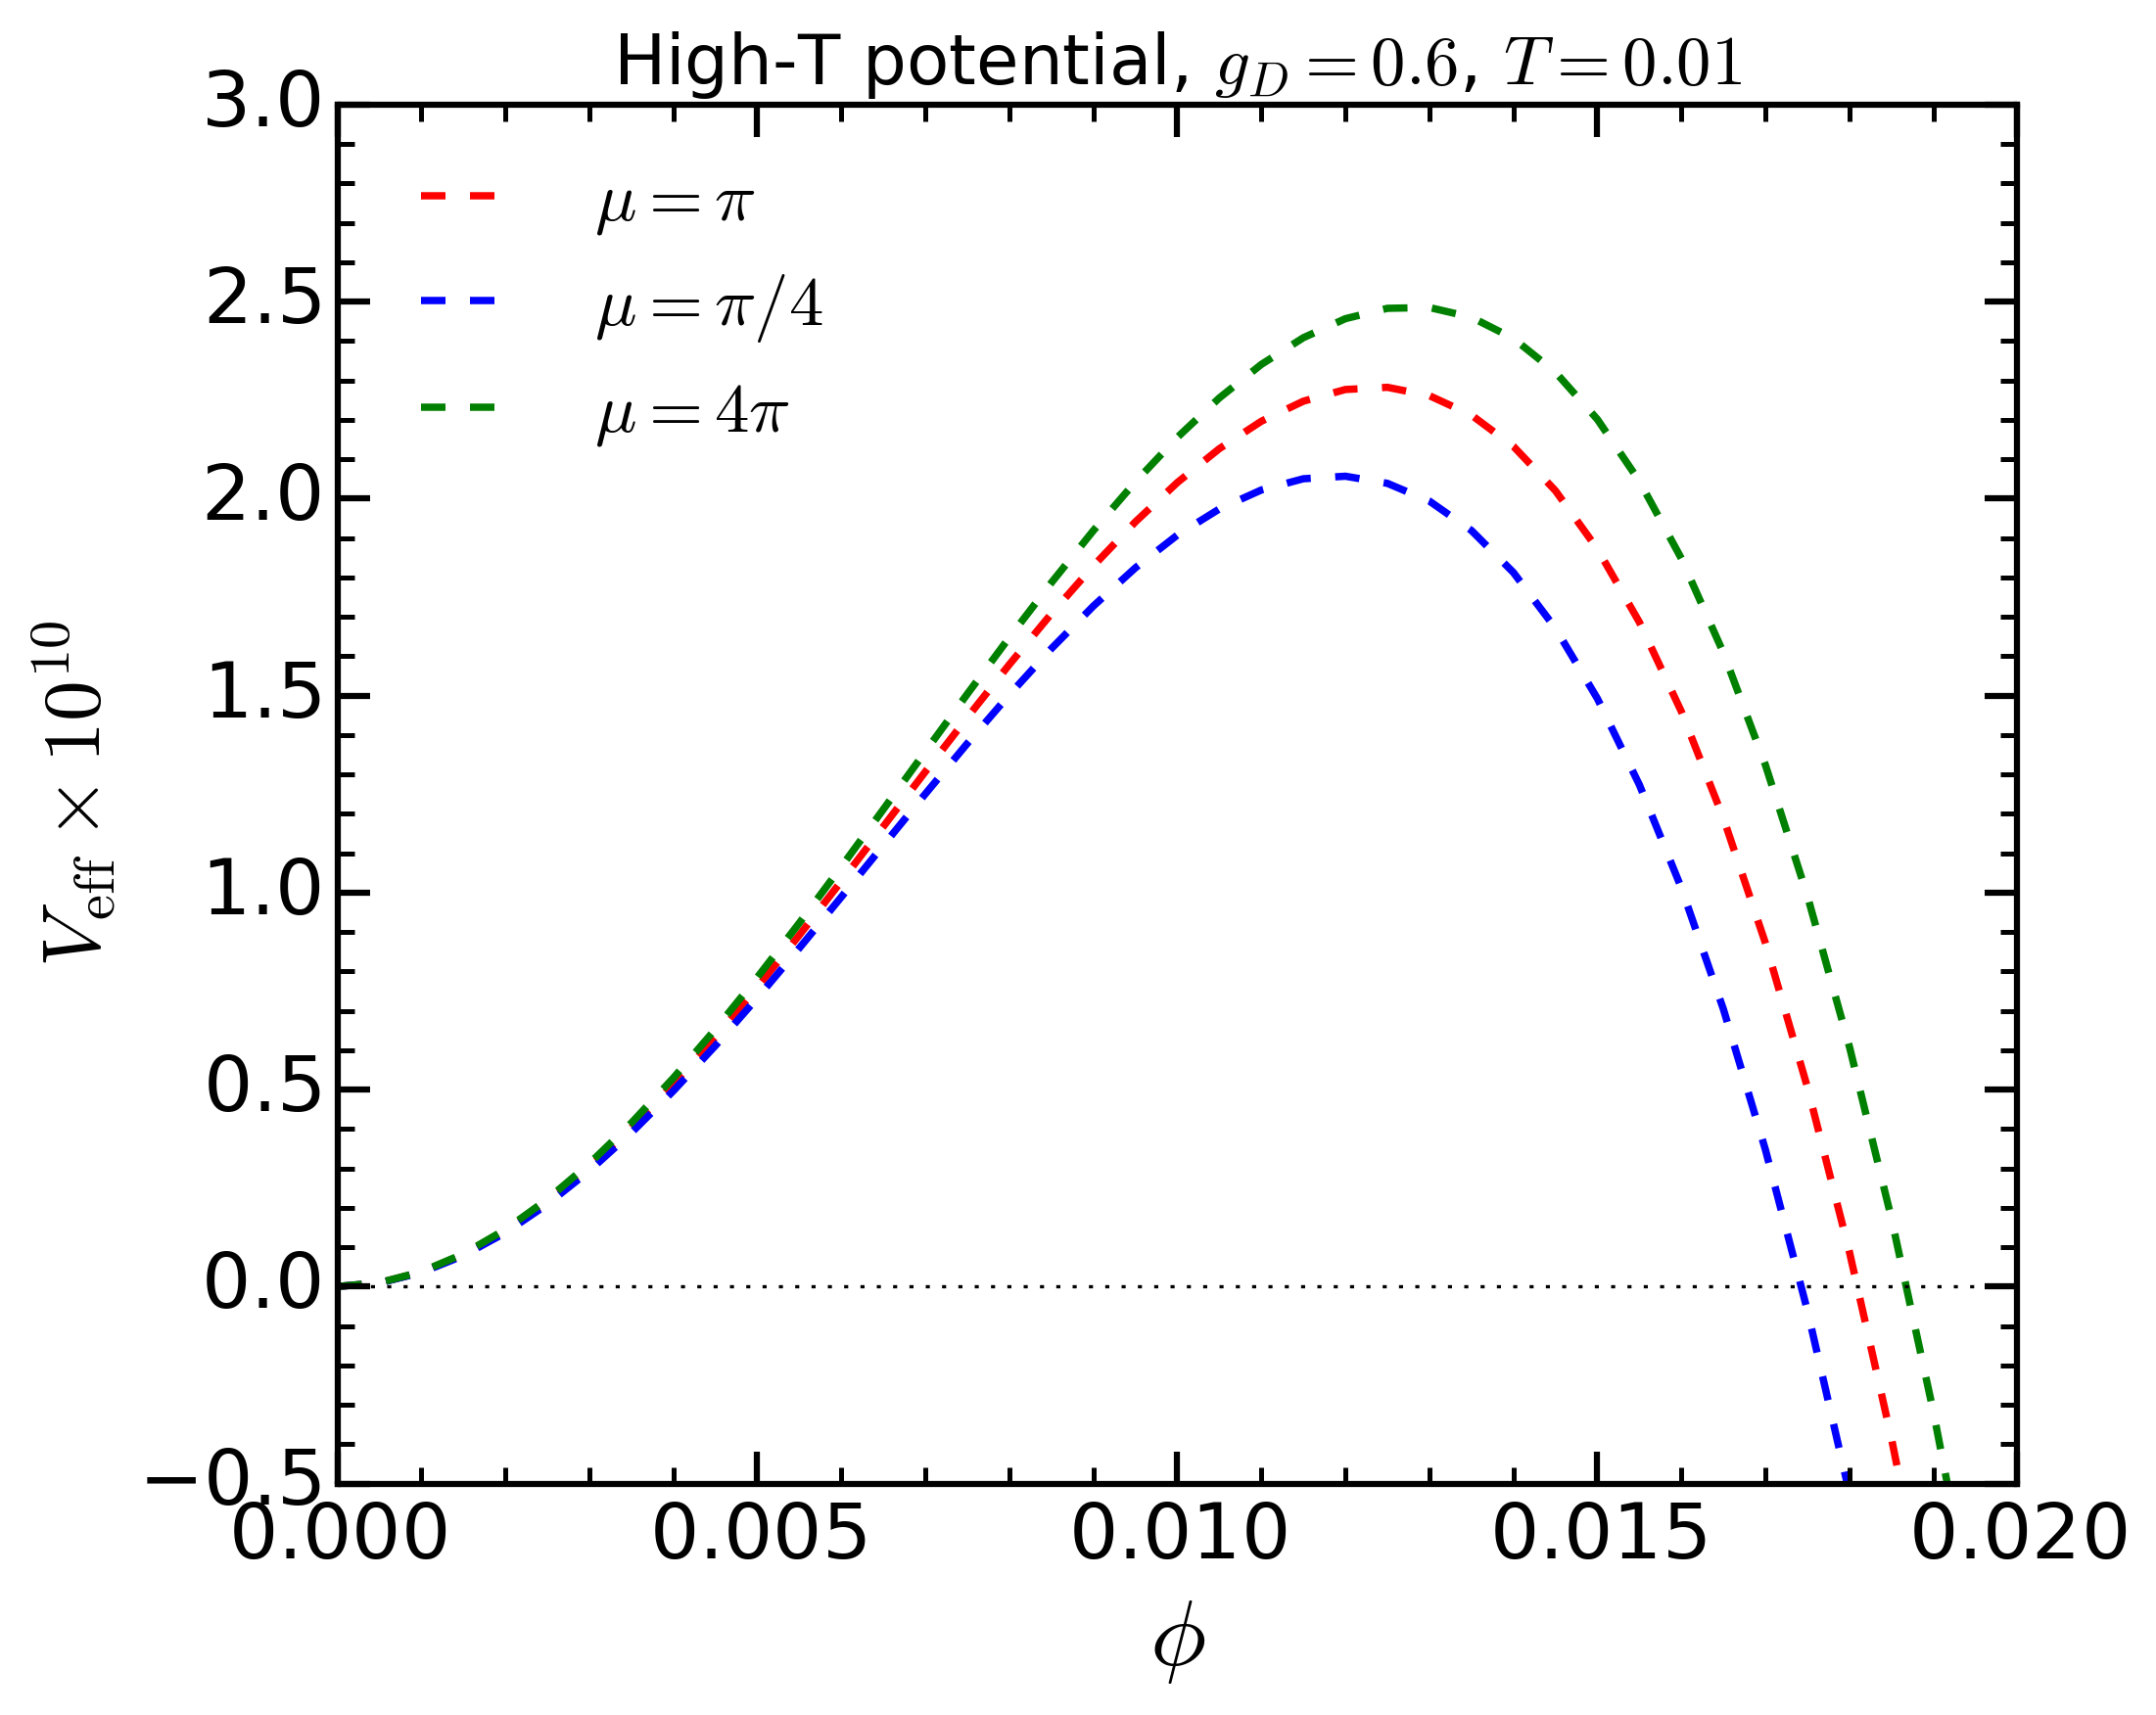

In [3]:
T_low = 0.01   # temperature much below the VEV

# Evaluate the high-T expanded potential at three renormalization scales
# (factor 1e10 rescales to visible units for gD=0.6, ls0~0)
y_pi      = V.Veff_HighT(S, T_low, gD0, np.pi,     ls0) * 1e10
y_pi_ov4  = V.Veff_HighT(S, T_low, gD0, np.pi/4,   ls0) * 1e10
y_pi_by4  = V.Veff_HighT(S, T_low, gD0, np.pi*4,   ls0) * 1e10

fig, ax = new_figure(figsize=(7.5, 6), dpi=300)
fig.patch.set_facecolor('white')

ax.plot(S, y_pi,     color='red',   ls='--', lw=1.8, label=r'$\mu = \pi$')
ax.plot(S, y_pi_ov4, color='blue',  ls='--', lw=1.8, label=r'$\mu = \pi/4$')
ax.plot(S, y_pi_by4, color='green', ls='--', lw=1.8, label=r'$\mu = 4\pi$')
ax.axhline(0, color='k', lw=0.8, ls=':')

ps.apply_standard_formatting(
    ax,
    ylog=False,
    xlabel=r'$\phi$',
    ylabel=r'$V_{\rm eff}\times 10^{10}$',
    title=fr'High-T potential, $g_D={gD0}$, $T={T_low}$',
    xlim=(0.0, 0.02),
    ylim=(-0.5, 3),
)
ax.legend(frameon = False, loc='best', ncol=1, fontsize=17)
plt.tight_layout()

In [ ]:
# Save the three curves for downstream use
np.savetxt(
    "../data/raw_data/V_full_curve_gD06_mu_piover4_to_pi4.dat",
    np.column_stack([S, y_pi, y_pi_ov4, y_pi_by4]),
    header="phi   V_ht_pi   V_ht_pi_over4   V_ht_pi_by4",
    fmt="%.10e"
)
print("Saved: data/raw_data/V_full_curve_gD06_mu_piover4_to_pi4.dat")

## 2. Thermal corrections

As $T$ increases toward the critical temperature $T_c$, the thermal mass lifts the broken minimum and eventually restores the $\phi\to 0$ symmetry. We compare the full potential `Veff` and the high-$T$ expansion `Veff_HighT` at several temperatures to show where the approximation breaks down.

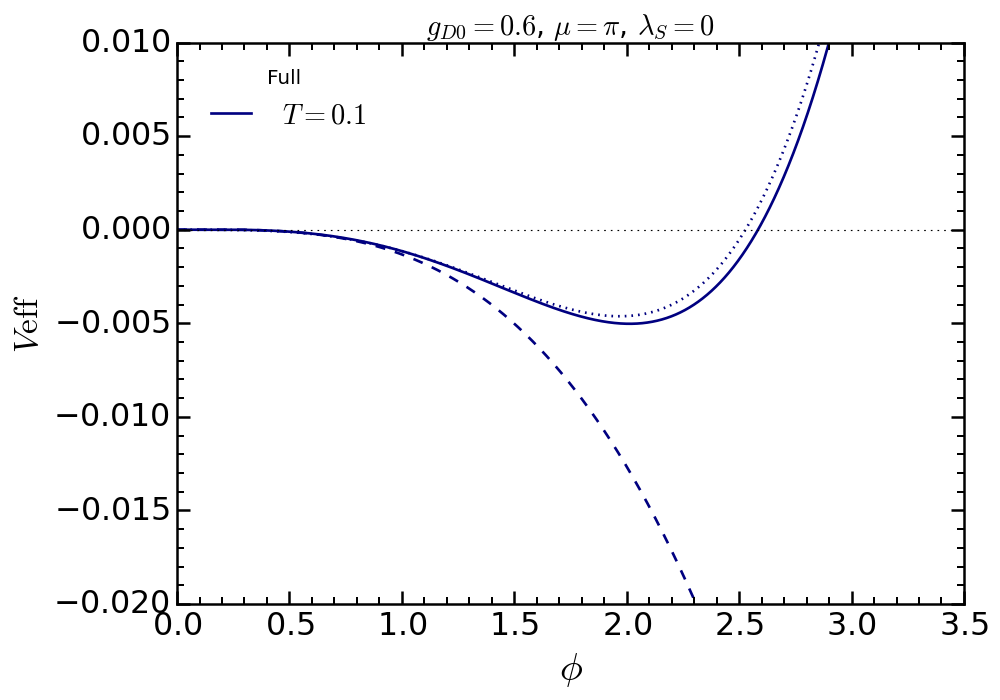

In [12]:

T_vals=[0.1]
ls0 = 0
gD0 = 0.6
scale = np.pi

colors_T = ['navy', 'royalblue', 'darkorange', 'crimson']

fig, ax = new_figure(figsize=(8.5, 6), dpi=120)
fig.patch.set_facecolor('white')

for T, c in zip(T_vals, colors_T):
    y_full = V.Veff(S, T, gD0, scale, ls0)
    y_ht   = V.Veff_HighT(S, T, gD0, scale, ls0)
    y_zero = V.Veff0(S, gD0, ls0)
 

    ax.plot(S, y_full , color=c, lw=1.6, ls='-',  label=fr'$T={T}$')
    ax.plot(S, y_ht  , color=c, lw=1.6, ls='--')
    ax.plot(S, y_zero, color=c, lw=1.6, ls=':')
ax.axhline(0, color='k', lw=0.7, ls=':')
ps.apply_standard_formatting(
    ax,
    ylog=False,
    xlabel=r'$\phi$',
    ylabel=r'$V{\rm eff}$',
    title=fr'$g_{{D0}}={gD0}$, $\mu=\pi$, $\lambda_S={ls0}$ ',
    xlim=(0, 3.5),
    ylim=(-0.02,0.01)
)
ax.legend(loc='best', frameon=False, fontsize=17, ncol = 1, title = 'Full')
plt.tight_layout()

In [3]:
# Evaluate potential at T=0.1 for gD0 = 0.6, ls0 = 0, s= 0.5 and print in table S vs V_eff. DO it for HT and full potential. Compare the two values. This is to check that the HT expansion is not too bad at T=0.1 for these parameters.

T=0.0001
ls0 = 0
gD0 = 0.6
scale = np.pi
S_table = np.array([0.5, 1.0, 1.5, 2.0])
V_table_full = V.Veff(S_table, T , gD0, scale, ls0)
V_table_ht = V.Veff_HighT(S_table, T , gD0, scale, ls0)
print(f" at T={T}, gD0={gD0}, ls0={ls0}, mu =  pi*T:")
print("-------------------------------")
print("S       V_eff_full       V_eff_HT")
for s, v, v_ht in zip(S_table, V_table_full, V_table_ht):

    print(f"{s:.1f}   {v:.3e}   {v_ht:.3e}")     

 at T=0.0001, gD0=0.6, ls0=0, mu =  pi*T:
-------------------------------
S       V_eff_full       V_eff_HT
0.5   -1.908e-04   -6.074e-04
1.0   -2.176e-03   -9.716e-03
1.5   -8.421e-03   -4.918e-02
2.0   -2.080e-02   -1.554e-01


---
## 3. Dark photon + Dirac fermion: effective potential

`VeffRGE_fermion` exposes the same interface as `VeffRGE` but adds:
- A **fermion Coleman–Weinberg loop**: $-\frac{4\,m_\chi^4}{64\pi^2}\!\left(\ln\frac{m_\chi^2}{\mu^2} - \frac{3}{2}\right)$, where $m_\chi = yS/\sqrt{2}$.
- A **fermionic thermal function**: $-\frac{4T^4}{2\pi^2} J_F(m_\chi^2/T^2)$ in $V_T$.
- **Modified Debye masses**: $\Pi_\phi$ gains $+y^2T^2/12$; $\Pi_{A'} = \frac{5}{12}g_D^2 T^2$.
- **Four running couplings** via `RGESolver_fermion`: $(g_D, \lambda_S, m_S^2, y)$.

Because no $J_B$ numerical table is needed, `Veff = Veff_HighT` throughout.

**Module used:** `src/RGE/VeffFunc_ferm_RGE.py`

In [3]:
# Instantiate fermion Veff with y0 = 0.3 baked in
Vf = veff_ferm.VeffRGE_fermion(y0=0)

gD0_f = 0.6
ls0_f = 0.0
scale = np.pi
S     = np.linspace(0.0, 5, 5000)

### 3.1 Scale variation at low temperature (fermion model)

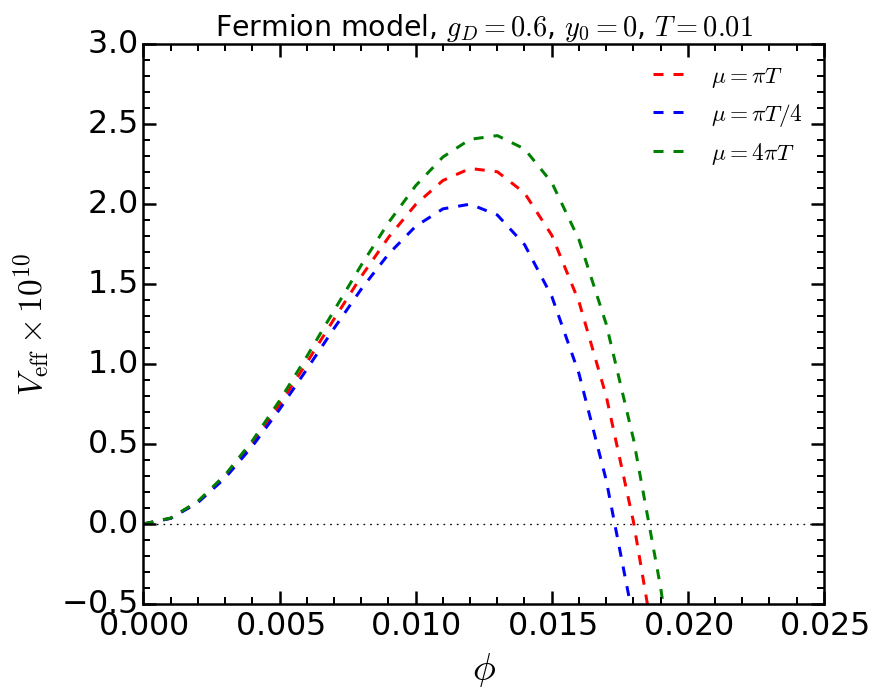

In [4]:
T_low = 0.01

yf_pi      = Vf.Veff_HighT(S, T_low, gD0_f, np.pi,   ls0_f) * 1e10
yf_pi_ov4  = Vf.Veff_HighT(S, T_low, gD0_f, np.pi/4, ls0_f) * 1e10
yf_pi_by4  = Vf.Veff_HighT(S, T_low, gD0_f, np.pi*4, ls0_f) * 1e10

fig, ax = new_figure(figsize=(7.5, 6), dpi=120)
fig.patch.set_facecolor('white')
ax.plot(S, yf_pi,     color='red',   ls='--', lw=1.8, label=r'$\mu = \pi T$')
ax.plot(S, yf_pi_ov4, color='blue',  ls='--', lw=1.8, label=r'$\mu = \pi T/4$')
ax.plot(S, yf_pi_by4, color='green', ls='--', lw=1.8, label=r'$\mu = 4\pi T$')
ax.axhline(0, color='k', lw=0.8, ls=':')
ps.apply_standard_formatting(
    ax, ylog=False,
    xlabel=r'$\phi$', ylabel=r'$V_{\rm eff}\times 10^{10}$',
    title=fr'Fermion model, $g_D={gD0_f}$, $y_0=0$, $T={T_low}$',
    xlim=(0.0, 0.025), ylim=(-0.5, 3),
)
ax.legend(frameon=False, fontsize=14)
plt.tight_layout()

### 3.2 Thermal evolution and comparison with no-fermion model

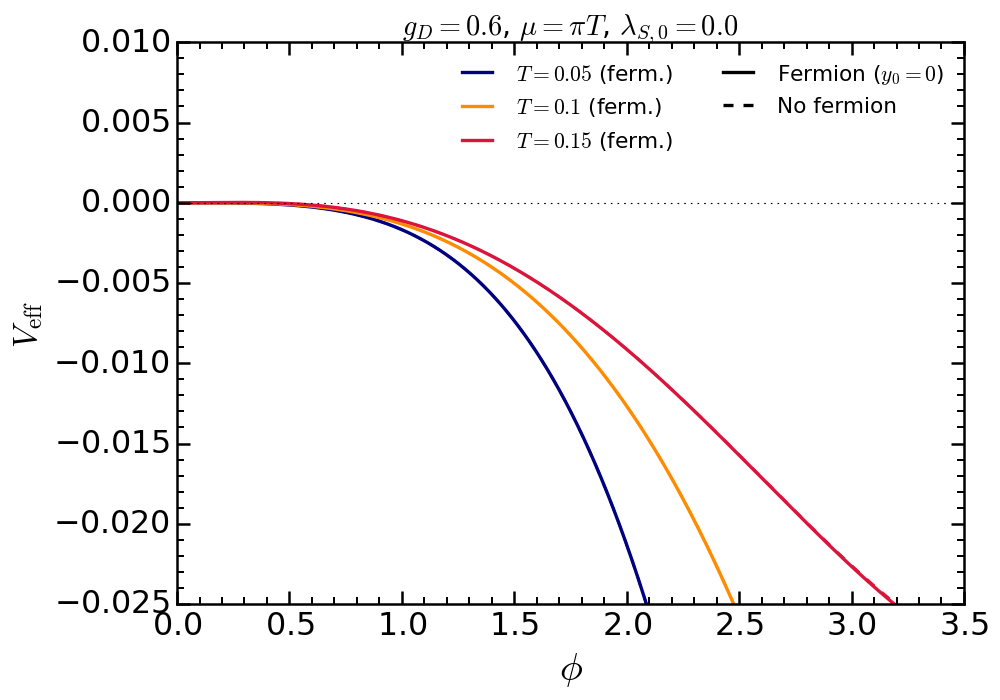

In [5]:
T_vals_f = [0.05, 0.1, 0.15]
colors_f = ['navy', 'darkorange', 'crimson']

fig, ax = new_figure(figsize=(8.5, 6), dpi=120)
fig.patch.set_facecolor('white')

for T, c in zip(T_vals_f, colors_f):
    y_ferm_T = Vf.Veff_HighT(S, T, gD0_f, scale, ls0_f)
    y_nofm_T = V.Veff_HighT(S, T, gD0,   scale, ls0)
    ax.plot(S, y_ferm_T, color=c,  lw=2.0, ls='-',  label=fr'$T={T}$ (ferm.)')
    ax.plot(S, y_nofm_T, color=c,  lw=1.5, ls='--')

ax.axhline(0, color='k', lw=0.7, ls=':')
ax.plot([], [], 'k-',  lw=2, label='Fermion ($y_0=0$)')
ax.plot([], [], 'k--', lw=2, label='No fermion')
ps.apply_standard_formatting(
    ax, ylog=False,
    xlabel=r'$\phi$', ylabel=r'$V_{\rm eff}$',
    title=fr'$g_D={gD0_f}$, $\mu=\pi T$, $\lambda_{{S,0}}={ls0_f}$',
    xlim=(0, 3.5), ylim=(-0.025, 0.01),
)
ax.legend(loc='best', frameon=False, fontsize=13, ncol=2)
plt.tight_layout()

In [6]:
# Evaluate potential HT at T=1e-4 for gD0 = 0.6, ls0 = 0, s= 0.5 and print in table S vs V_eff. DO it for HT  with fermion and without fermion. Compare the two values. This is to check the impact of the fermion on the potential at low T. ONLY for HT cases

T=0.0001
ls0 = 0
gD0 = 0.6
scale = np.pi
S_table = np.array([0.5, 1.0, 1.5, 2.0])
V_table_full = V.Veff_HighT(S_table, T , gD0, scale, ls0)
V_table_ferm = Vf.Veff_HighT(S_table, T , gD0, scale, ls0)
print(f" at T={T}, gD0={gD0}, ls0={ls0}, mu =  pi*T:")
print("--------------------------------------------------")
print("S       V_eff_HT_no_fermion       V_eff_HT_with_fermion")
for s, v_no_fm, v_fm in zip(S_table, V_table_full, V_table_ferm):
    print(f"{s:.1f}     {v_no_fm:.3e}                {v_fm:.3e}")


 at T=0.0001, gD0=0.6, ls0=0, mu =  pi*T:
--------------------------------------------------
S       V_eff_HT_no_fermion       V_eff_HT_with_fermion
0.5     -6.074e-04                -6.008e-04
1.0     -9.716e-03                -9.610e-03
1.5     -4.918e-02                -4.865e-02
2.0     -1.554e-01                -1.538e-01


---
## 4. Comparison with external data: fermion model ($y_0 = 0$)

Evaluates $V_{\rm eff}(\phi, T)$ using `VeffRGE_fermion` with $y_0 = 0$ (Yukawa off) at the three temperatures
$T \in \{10^{-5},\,10^{-3},\,10^{-1}\}$ GeV.

Even with $y_0 = 0$ the fermion model differs from the no-fermion case through the dark-photon Debye mass:
$$\Pi_{A'} = \tfrac{5}{12}\,g_D^2\,T^2 \quad \text{(scalar + fermion)} \quad \text{vs} \quad \tfrac{1}{3}\,g_D^2\,T^2 \quad \text{(scalar only).}$$

The potential curves are saved to `data/raw_data/Veff_ferm_y0_gD06_comparison.dat` for offline comparison.

In [7]:
# Parameters matching the external data request
g0   = 0.6
y0   = 0.0
lam0 = 0.0
m0   = 0.0        # mS02 = 0
scale = np.pi

Ts   = [1e-5, 1e-3, 1e-1]
phis = np.linspace(0.0, 2.5, 1001)

# Fermion-model potential with Yukawa set to zero
Vfcomp = veff_ferm.VeffRGE_fermion(y0=y0, mS02=m0)

Saved: data/raw_data/Veff_ferm_y0_gD06_comparison.dat
phi: 0.000 to 2.500,  1001 points
Temperatures: [1e-05, 0.001, 0.1]


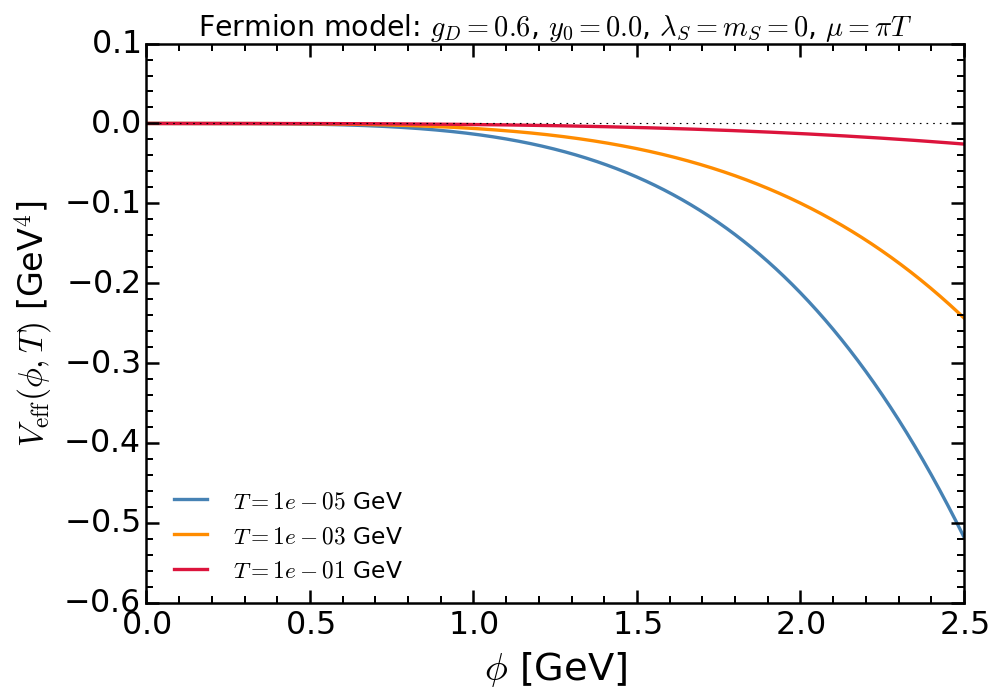

In [10]:
colors_comp = ['steelblue', 'darkorange', 'crimson']

fig, ax = new_figure(figsize=(8.5, 6), dpi=120)
fig.patch.set_facecolor('white')

all_columns = [phis]
header_parts = ['phi']

for T, c in zip(Ts, colors_comp):
    Vvals = Vfcomp.Veff_HighT(phis, T, g0, scale, lam0)
    ax.plot(phis, Vvals, color=c, lw=2.0, label=fr'$T = {T:.0e}$ GeV')
    all_columns.append(Vvals)
    header_parts.append(f'Veff_T{T:.0e}')

ax.axhline(0, color='k', lw=0.7, ls=':')
ps.apply_standard_formatting(
    ax, ylog=False,
    xlabel=r'$\phi$ [GeV]',
    ylabel=r'$V_{\rm eff}(\phi, T)$ [GeV$^4$]',
    title=fr'Fermion model: $g_D={g0}$, $y_0={y0}$, $\lambda_S=m_S=0$, $\mu=\pi T$',
    xlim=(0, 2.5),
)
ax.legend(loc='best', frameon=False, fontsize=14)
plt.tight_layout()

# Save curves for comparison with external data
np.savetxt(
    "data/raw_data/Veff_ferm_y0_gD06_comparison.dat",
    np.column_stack(all_columns),
    header='  '.join(header_parts) + f'\n# g0={g0}  y0={y0}  lam0={lam0}  m0={m0}  scale=pi',
    fmt='%.10e',
)
print("Saved: data/raw_data/Veff_ferm_y0_gD06_comparison.dat")
print(f"phi: {phis[0]:.3f} to {phis[-1]:.3f},  {len(phis)} points")
print(f"Temperatures: {Ts}")

In [49]:
jdata = np.loadtxt(
    "data/raw_data/Vphi_g=0.6_y=0.0_Ts.txt",
    skiprows=1,
    unpack=True,
)
mdata = np.loadtxt(
    "data/raw_data/Veff_ferm_y0_gD06_comparison.dat",
    skiprows=1,
    unpack=True,
)

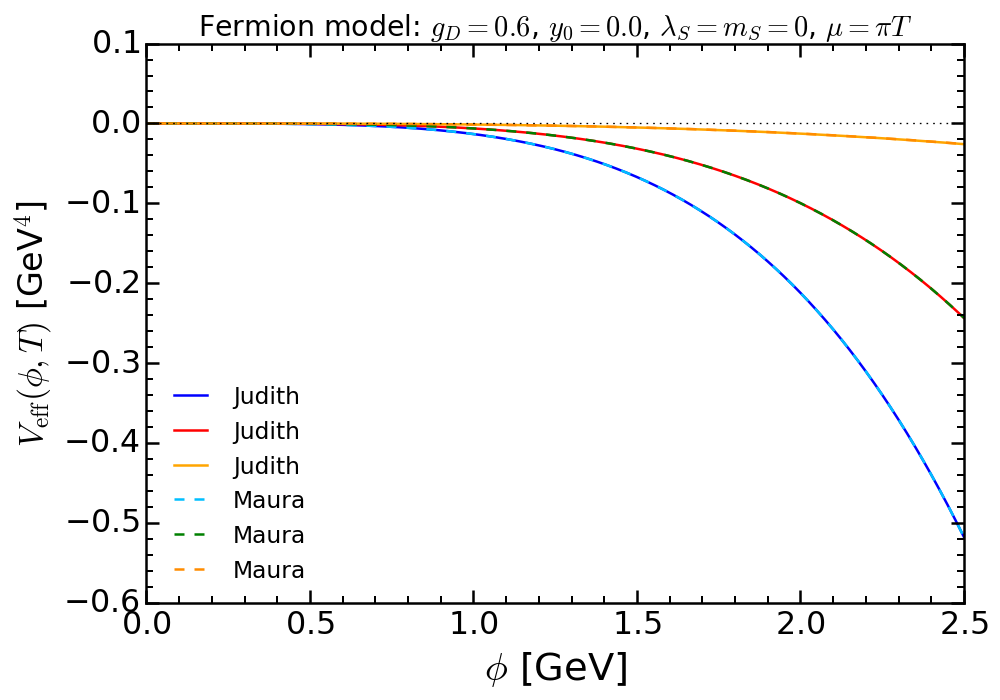

In [85]:
# Plot the external data for comparison jdata & mdata. 3 different plots for each T in jdata, and the three curves from mdata on the same plot for comparison. This is to check that the external data matches our calculations for the same parameters.

fig, ax = new_figure(figsize=(8.5, 6), dpi=120)
fig.patch.set_facecolor('white')
plt.plot(jdata[0], jdata[1], label='Judith', color='blue', lw=1.5)
plt.plot(jdata[0], jdata[2], label='Judith', color='red', lw=1.5)
plt.plot(jdata[0], jdata[3], label='Judith', color='orange', lw=1.5)
plt.plot(mdata[0], mdata[1], label='Maura', color='deepskyblue', lw=1.5, ls='--')
plt.plot(mdata[0], mdata[2], label='Maura', color='green', lw=1.5, ls='--')
plt.plot(mdata[0], mdata[3], label='Maura', color='darkorange', lw=1.5, ls='--')
plt.axhline(0, color='k', lw=0.8, ls=':')

ps.apply_standard_formatting(
    ax, ylog=False,
    xlabel=r'$\phi$ [GeV]',
    ylabel=r'$V_{\rm eff}(\phi, T)$ [GeV$^4$]',
    title=fr'Fermion model: $g_D={g0}$, $y_0={y0}$, $\lambda_S=m_S=0$, $\mu=\pi T$',
    #xlim=(0, 2.5),
)
plt.legend(loc='best', frameon=False, fontsize=14)
plt.tight_layout()          


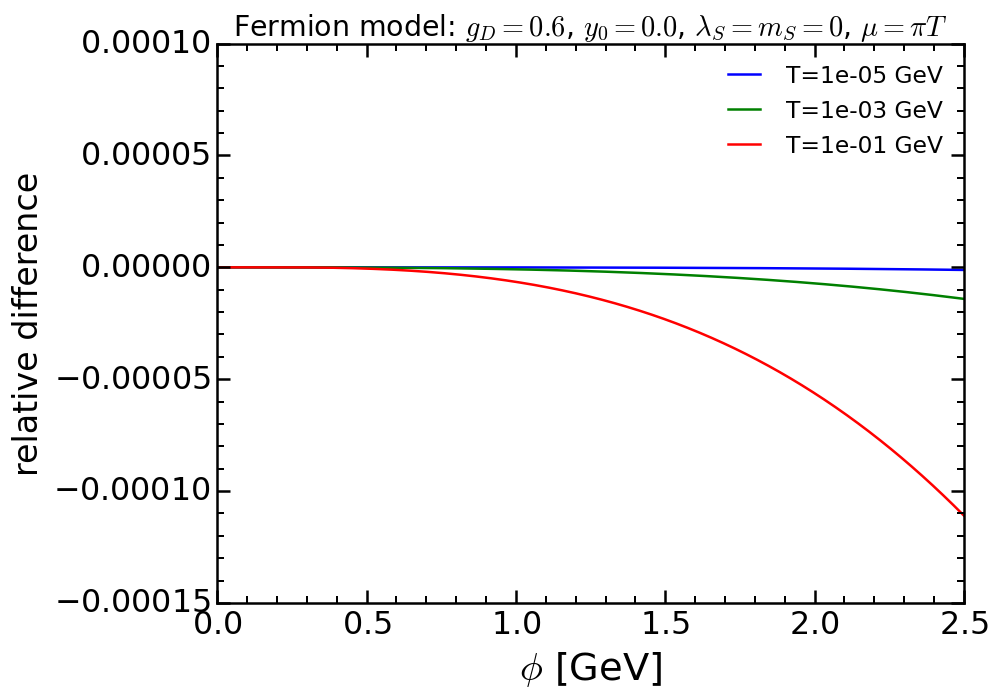

In [83]:
# plot relative difference between jdata & mdata for the three T values. This is to check the relative difference between the two calculations and see if they are consistent within a certain tolerance.

fig, ax = new_figure(figsize=(8.5, 6), dpi=120)
fig.patch.set_facecolor('white')
for i in range(1, 4):
    plt.plot(jdata[0], jdata[i] - mdata[i], label=f'T={Ts[i-1]:.0e} GeV', lw=1.5)

ps.apply_standard_formatting(
    ax, 
    xlog=False, ylog=False,
    xlabel=r'$\phi$ [GeV]',
    ylabel=r'relative difference',
    title=fr'Fermion model: $g_D={g0}$, $y_0={y0}$, $\lambda_S=m_S=0$, $\mu=\pi T$',
   ylim=(-0.00015, 0.0001),
)

plt.legend(loc='best', frameon=False, fontsize=14)
plt.tight_layout()  

/var/folders/y8/6tlplz1d2w1dk6qd5rz9z4m80000gn/T/ipykernel_27067/3792136485.py:8: RuntimeWarning: invalid value encountered in divide
  plt.plot(jdata[0], jdata[i] / mdata[i], label=f'T={Ts[i-1]:.0e} GeV', lw=1.5)


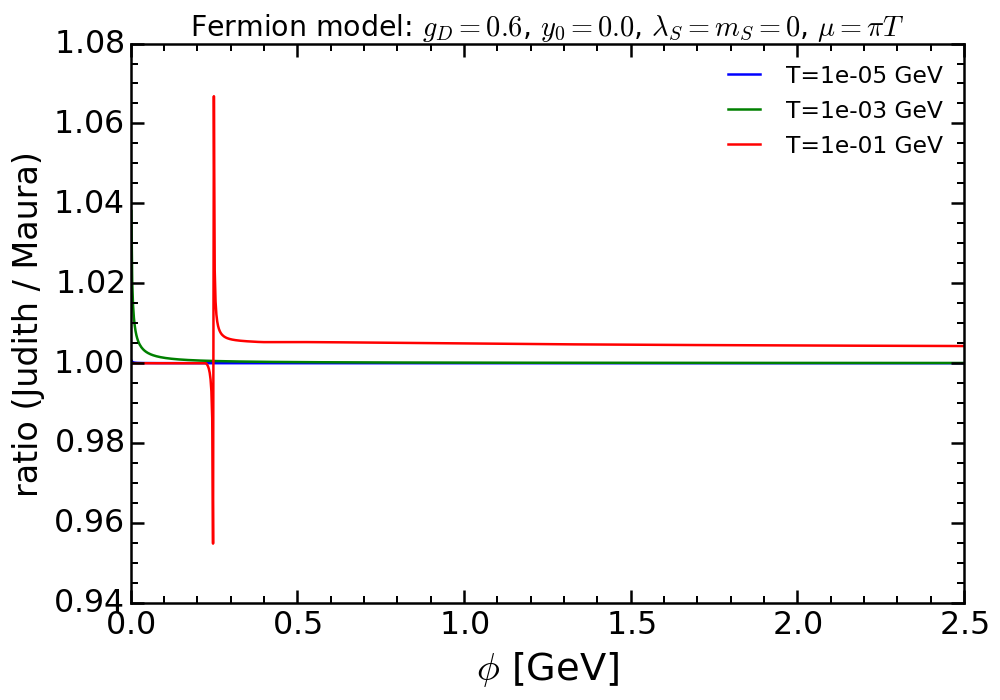

In [66]:
# Plot the rate between jdata and mdata for the three values f T. This is judit data vs Maura data. use apply_standard_formatting with ylog=True and xlog=True. This is to check the ratio between the two calculations and see if they are consistent within a certain tolerance across the range of phi values.
from startup import new_figure


fig, ax = new_figure(figsize=(8.5, 6), dpi=120)
fig.patch.set_facecolor('white')
for i in range(1, 4):
    plt.plot(jdata[0], jdata[i] / mdata[i], label=f'T={Ts[i-1]:.0e} GeV', lw=1.5)
ps.apply_standard_formatting(
    ax,
    ylog=False, xlog=False,
    xlabel=r'$\phi$ [GeV]',
    ylabel=r'ratio (Judith / Maura)',
    title=fr'Fermion model: $g_D={g0}$, $y_0={y0}$, $\lambda_S=m_S=0$, $\mu=\pi T$',

)
plt.legend(loc='best', frameon=False, fontsize=14)
plt.tight_layout()      